<a href="https://colab.research.google.com/github/ShaneM-93/diabetes-prediction-classification-ml/blob/main/data_cleaning_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#importing libraries for data cleaning and visualisation.
import seaborn as sns
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/ShaneM-93/diabetes-prediction-classification-ml/refs/heads/main/data/diabetes.csv")

#display first 5 lines of the data to see if it has been read in correctly.
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
#checking the data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


All the data is in the correct data type.

In [4]:
df.describe()
#stastisical summary of the data to identify unusual patterns/values.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


The statistical summary shows that the BMI data may have some incorrect values as a BMI of 67.1 is highly unlikely, and insulin max values of 846 is also impossible. Max values of pregnancies being 17 is unlikely but still possible so these values will be ignored.

In [5]:
df.isna().sum()
#counting the amount of missing values in the data set.

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


There are no Nan values but it doesn't guarantee there aren't any missing values still as the data section may have been populated with a different value/phrase.

We know that the data only contains integers and floats from (df.info [10]) however we need to rule out a 0 integer as this is statistically impossible but still could have been used to fill a missing number.

In [6]:
# Identifying zero numbers
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]

for col in cols:
  print(col, (df[col] == 0).sum())

Pregnancies 111
Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11
DiabetesPedigreeFunction 0
Age 0


As you can see all columns that have zero numbers in them, other than pregnancies are statistically impossible, therefore we will have to remove the data from these columns and replace with the median values of each column.

In [9]:
#Replacing zero values with the median of each column in the data set.
cols = ['Glucose', 'BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    median_value = df[col].replace(0, pd.NA).median()
    df[col] = df[col].replace(0, median_value)


In [10]:
#Checking for duplicated values in the data set.
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


No duplicated values spotted in the data.

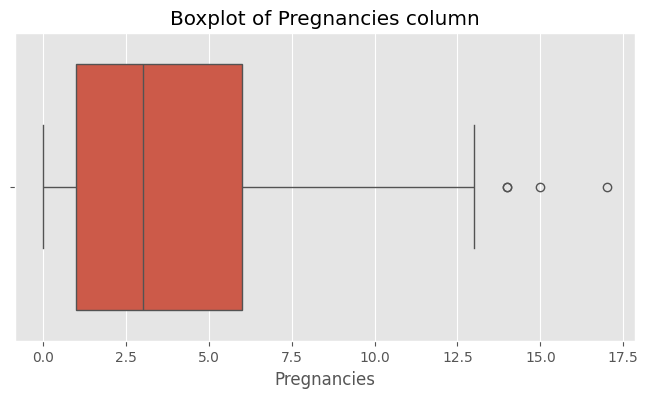

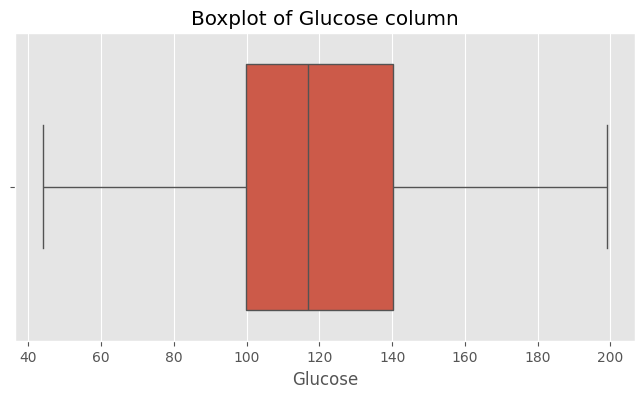

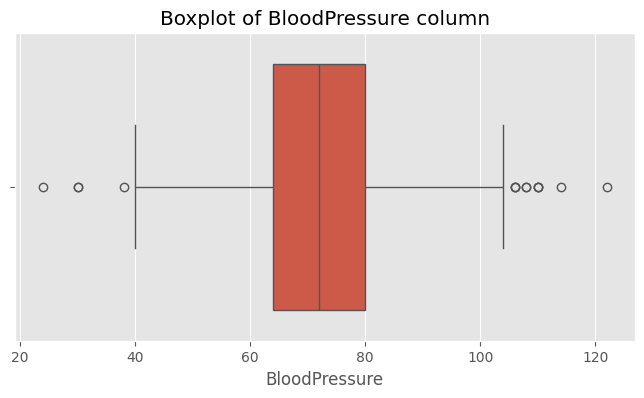

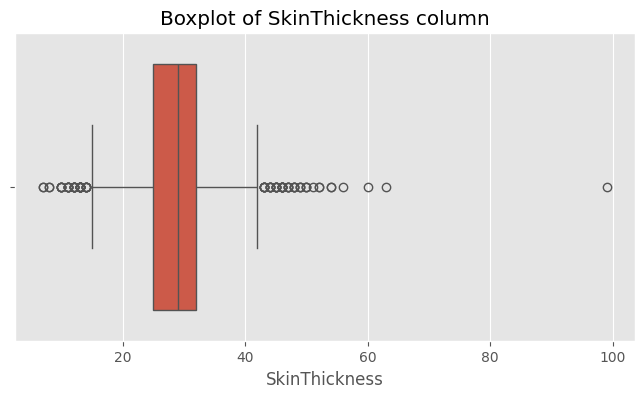

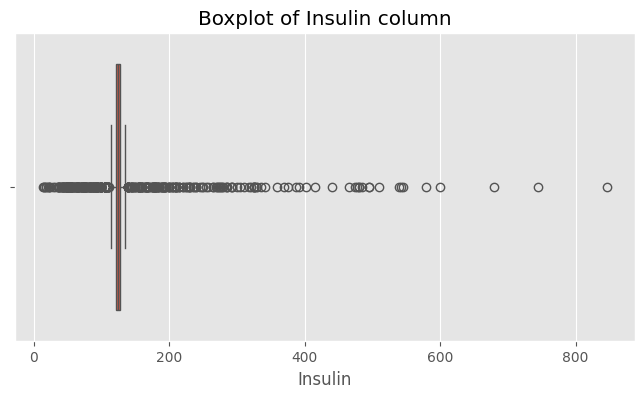

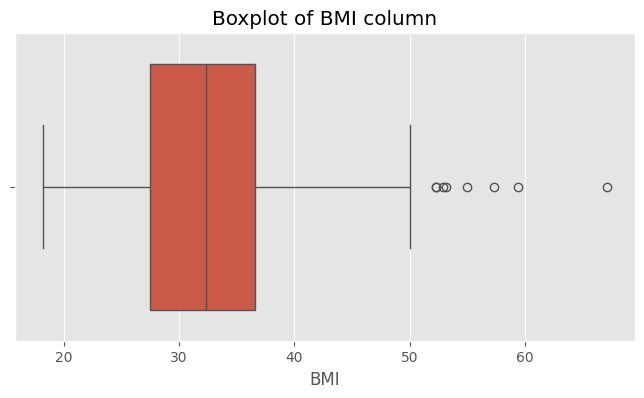

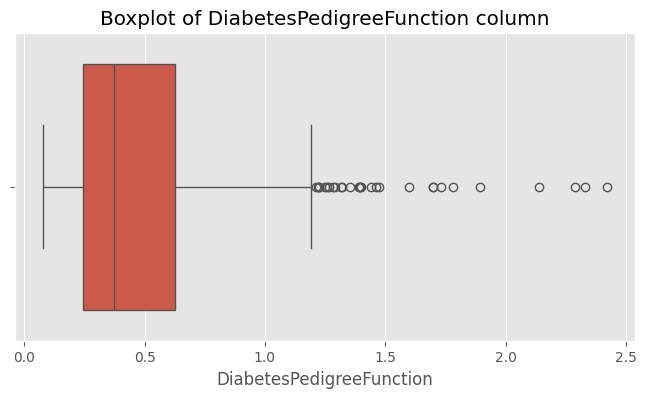

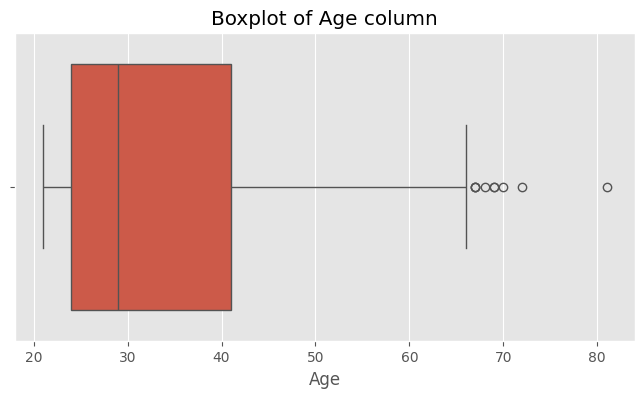

In [11]:
#Viewing data in a boxplot for outliers.
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

for col in df.columns[:-1]:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col} column")
    plt.show()

The higher pregnancy values are possible, although unlikely. (17 pregnancies) so these will not be removed.

Glucose chart is normal with no outliers. (the zero value was removed already)

For the blood pressure chart the values below the lower quartile or whisker are not possible so these need removing.

For the skin thickness column the outlier at approximately 100 needs removing as it's extremely far from the rest of the outliers and the upper quartile.

Insulin chart is ok as it has a wide range of values and no particular order.

diabetes and BMI is ok as they rely on genetics and all values are possible.

Age is also possible at approx 80 years old.





Based on all the comments above the values below the lower quartile in blood pressure need removing

The value at approx 100 in skin thickness needs removing.

In [12]:
col = "BloodPressure"

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

lower_whisker = q1 - 1.5 * iqr

df = df[df[col] >= lower_whisker]

<Axes: xlabel='BloodPressure'>

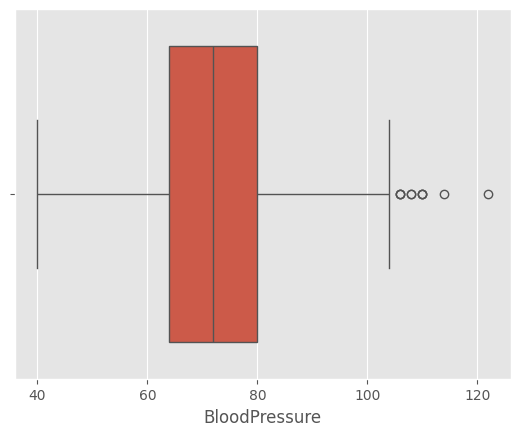

In [14]:
 sns.boxplot(data=df, x="BloodPressure")

<Axes: xlabel='SkinThickness'>

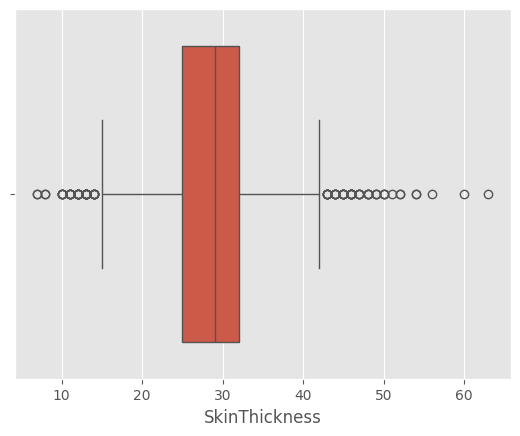

In [17]:
df = df[(df["SkinThickness"] < 95)]
sns.boxplot(data=df,x="SkinThickness")